# Individual Homework 4 — From Accuracy to Accountability: Stress Testing a Predictive Model

**Course:** DNSC 6330 Responsible Machine Learning  
**Student:** Zuleirys Santana Rodriguez  
**Lecture reference:** Lecture 04, `DNSC_6330_Lecture-04.pdf`

This notebook extends the COMPAS workflow from the earlier assignments and turns it into a reliability audit. The analysis keeps the same general modeling setup used previously so that the results remain comparable, then evaluates the model through five audit lenses required in Lecture 04:

1. Distribution drift
2. Generalization
3. Spurious-correlation probing through attribute swaps
4. Robustness to perturbations in `priors_count`
5. Slice-based evaluation by race, sex, and age

The goal is not just to report metrics, but to explain what they suggest, what they miss, and what governance actions they justify.

## Submission Checklist And Rubric Alignment

This notebook is structured to match the lecture instructions and the grading guidance shown in Lecture 04.

- **Correctness of implementation:** each required coding section is implemented directly in Python and executed in sequence.
- **Code clarity and reproducibility:** the notebook is standalone, reads the local COMPAS CSV from the same folder, uses fixed random seeds, and runs top to bottom without relying on the earlier notebooks.
- **Interpretation quality:** every major section includes a short interpretation block that explains what the metrics mean rather than only printing them.
- **Evidence of audit-level reasoning:** the notebook closes with a governance-oriented memo that connects the technical findings to oversight actions, limitations, and deployment risk.

The assignment requirements covered here are:

1. Distribution drift: PSI, KS, MMD, and train-test score distributions
2. Generalization: AUC, accuracy, log loss, and overfitting gaps
3. Spurious-correlation probe: protected-attribute swap tests and probability deltas
4. Robustness: `priors_count` stress test, ICE curves, and sensitivity summaries
5. Slice-based evaluation: race, sex, and age-category performance comparisons

This design follows the professor's instruction not to just report metrics, but to explain what they mean, what they miss, and what actions they justify.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, confusion_matrix
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 100)

## Load And Prepare The COMPAS Data

The notebook first reconstructs the cleaned COMPAS cohort used throughout the earlier assignments. I keep the same filters and the same overall predictive setup so the Assignment 4 audit is evaluating a directly comparable pipeline rather than a brand-new model.

In [2]:
DATA_PATH = Path("compas-scores-two-years.csv")
FALLBACK_URL = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"

if DATA_PATH.exists():
    raw_data = pd.read_csv(DATA_PATH)
    data_source = str(DATA_PATH)
else:
    raw_data = pd.read_csv(FALLBACK_URL)
    data_source = FALLBACK_URL

raw_data.shape, data_source

((7214, 53), 'compas-scores-two-years.csv')

In [3]:
def prepare_compas_frame(raw_df: pd.DataFrame) -> pd.DataFrame:
    df = raw_df[
        [
            "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
            "priors_count", "days_b_screening_arrest", "decile_score",
            "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
        ]
    ].copy()

    df = df[df["days_b_screening_arrest"].between(-30, 30)]
    df = df[df["is_recid"] != -1]
    df = df[df["c_charge_degree"] != "O"]
    df = df[df["score_text"] != "N/A"].copy()

    for col in ["c_jail_in", "c_jail_out"]:
        df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)
        df[f"{col}_num"] = df[col].map(lambda x: x.timestamp() if pd.notnull(x) else np.nan)
        df[f"{col}_num"] = df[f"{col}_num"].fillna(df[f"{col}_num"].median())

    df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days
    df["length_of_stay"] = df["length_of_stay"].fillna(df["length_of_stay"].median())
    df["score_binary"] = (df["score_text"] != "Low").astype(int)

    return df.reset_index(drop=True)


df = prepare_compas_frame(raw_data)
df.shape

(6172, 17)

In [4]:
target = "two_year_recid"

numeric_features = [
    "age",
    "priors_count",
    "decile_score",
    "days_b_screening_arrest",
    "is_recid",
    "c_jail_in_num",
    "c_jail_out_num",
    "length_of_stay",
]

categorical_features = [
    "age_cat",
    "sex",
    "race",
    "c_charge_degree",
    "score_text",
]

features = numeric_features + categorical_features
X = df[features].copy()
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", encoder, categorical_features),
    ]
)

lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)

gbt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42)),
    ]
)

lr_pipeline.fit(X_train, y_train)
gbt_pipeline.fit(X_train, y_train)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
df.head()

Train shape: (4937, 13)
Test shape: (1235, 13)


,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,c_jail_in_num,c_jail_out_num,length_of_stay,score_binary
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,1.376374e+09,1.376459e+09,0,0
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,1.359172e+09,1.360043e+09,10,0
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,1.365829e+09,1.365923e+09,1,0
3,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,1.385787e+09,1.385901e+09,1,0
4,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,1.392700e+09,1.393244e+09,6,1


## Part A — Distribution Drift

Lecture 04 starts by asking whether the train and test distributions meaningfully differ. I evaluate that question in three ways:

- **PSI** and **KS** for the numeric features
- **MMD** in the fully encoded feature space
- a direct comparison of the predicted score distributions between train and test

The point is not to claim that every difference is harmful. The point is to identify where the deployment distribution may be different enough to make average performance misleading.

In [5]:
def population_stability_index(train_series: pd.Series, test_series: pd.Series, bins: int = 10) -> float:
    quantiles = np.linspace(0, 1, bins + 1)
    edges = np.unique(np.quantile(train_series, quantiles))

    if len(edges) < 2:
        return np.nan

    edges = edges.astype(float)
    edges[0] -= 1e-9
    edges[-1] += 1e-9

    train_counts, _ = np.histogram(train_series, bins=edges)
    test_counts, _ = np.histogram(test_series, bins=edges)

    train_pct = np.clip(train_counts / train_counts.sum(), 1e-6, None)
    test_pct = np.clip(test_counts / test_counts.sum(), 1e-6, None)

    return float(np.sum((test_pct - train_pct) * np.log(test_pct / train_pct)))


def psi_label(value: float) -> str:
    if pd.isna(value):
        return "insufficient variation"
    if value < 0.10:
        return "low drift"
    if value < 0.25:
        return "moderate drift"
    return "high drift"


drift_rows = []
for feature in numeric_features:
    psi = population_stability_index(X_train[feature], X_test[feature], bins=10)
    ks_stat, ks_p = stats.ks_2samp(X_train[feature], X_test[feature])
    drift_rows.append(
        {
            "feature": feature,
            "train_mean": X_train[feature].mean(),
            "test_mean": X_test[feature].mean(),
            "mean_shift": X_test[feature].mean() - X_train[feature].mean(),
            "psi": psi,
            "psi_flag": psi_label(psi),
            "ks_stat": ks_stat,
            "ks_pvalue": ks_p,
        }
    )

drift_table = pd.DataFrame(drift_rows).sort_values(["psi", "ks_stat"], ascending=False)
drift_table

,feature,train_mean,test_mean,mean_shift,psi,psi_flag,ks_stat,ks_pvalue
7,length_of_stay,1.447235e+01,1.522429e+01,0.751940,0.013529,low drift,0.014125,0.987320
2,decile_score,4.452299e+00,4.283401e+00,-0.168898,0.012212,low drift,0.029085,0.365048
0,age,3.444339e+01,3.489879e+01,0.455399,0.010131,low drift,0.035891,0.152404
5,c_jail_in_num,1.379693e+09,1.379391e+09,-301708.956443,0.009662,low drift,0.024389,0.589019
6,c_jail_out_num,1.380986e+09,1.380747e+09,-238671.395791,0.008178,low drift,0.021741,0.728715
3,days_b_screening_arrest,-1.765647e+00,-1.638866e+00,0.126781,0.006785,low drift,0.025044,0.554646
1,priors_count,3.261697e+00,3.185425e+00,-0.076272,0.003980,low drift,0.023077,0.658166
4,is_recid,4.855175e-01,4.801619e-01,-0.005356,0.000000,low drift,0.005356,1.000000


In [6]:
train_encoded = gbt_pipeline.named_steps["preprocessor"].transform(X_train)
test_encoded = gbt_pipeline.named_steps["preprocessor"].transform(X_test)

if hasattr(train_encoded, "toarray"):
    train_encoded = train_encoded.toarray()
if hasattr(test_encoded, "toarray"):
    test_encoded = test_encoded.toarray()

rng = np.random.default_rng(42)
train_idx = rng.choice(len(train_encoded), size=min(400, len(train_encoded)), replace=False)
test_idx = rng.choice(len(test_encoded), size=min(400, len(test_encoded)), replace=False)

train_sample = train_encoded[train_idx]
test_sample = test_encoded[test_idx]
combined = np.vstack([train_sample, test_sample])

sq_dists = ((combined[:, None, :] - combined[None, :, :]) ** 2).sum(axis=2)
nonzero_sq = sq_dists[sq_dists > 0]
gamma = 1.0 / np.median(nonzero_sq) if len(nonzero_sq) else 1.0 / combined.shape[1]

K_xx = rbf_kernel(train_sample, train_sample, gamma=gamma)
K_yy = rbf_kernel(test_sample, test_sample, gamma=gamma)
K_xy = rbf_kernel(train_sample, test_sample, gamma=gamma)

mmd_value = float(K_xx.mean() + K_yy.mean() - 2 * K_xy.mean())

score_distribution = []
for label, pipeline in [("Logistic Regression", lr_pipeline), ("Gradient-Boosted Tree", gbt_pipeline)]:
    train_scores = pipeline.predict_proba(X_train)[:, 1]
    test_scores = pipeline.predict_proba(X_test)[:, 1]
    ks_stat, ks_p = stats.ks_2samp(train_scores, test_scores)
    score_distribution.append(
        {
            "model": label,
            "train_score_mean": train_scores.mean(),
            "test_score_mean": test_scores.mean(),
            "mean_gap": test_scores.mean() - train_scores.mean(),
            "train_score_std": train_scores.std(),
            "test_score_std": test_scores.std(),
            "score_ks_stat": ks_stat,
            "score_ks_pvalue": ks_p,
        }
    )

score_drift_table = pd.DataFrame(score_distribution)
print(f"Encoded-space MMD (RBF kernel): {mmd_value:.4f}")
score_drift_table

Encoded-space MMD (RBF kernel): 0.0026


,model,train_score_mean,test_score_mean,mean_gap,train_score_std,test_score_std,score_ks_stat,score_ks_pvalue
0,Logistic Regression,0.455175,0.450125,-0.005049,0.470134,0.469746,0.023347,0.644187
1,Gradient-Boosted Tree,0.455087,0.457692,0.002605,0.478054,0.478473,0.033073,0.224108


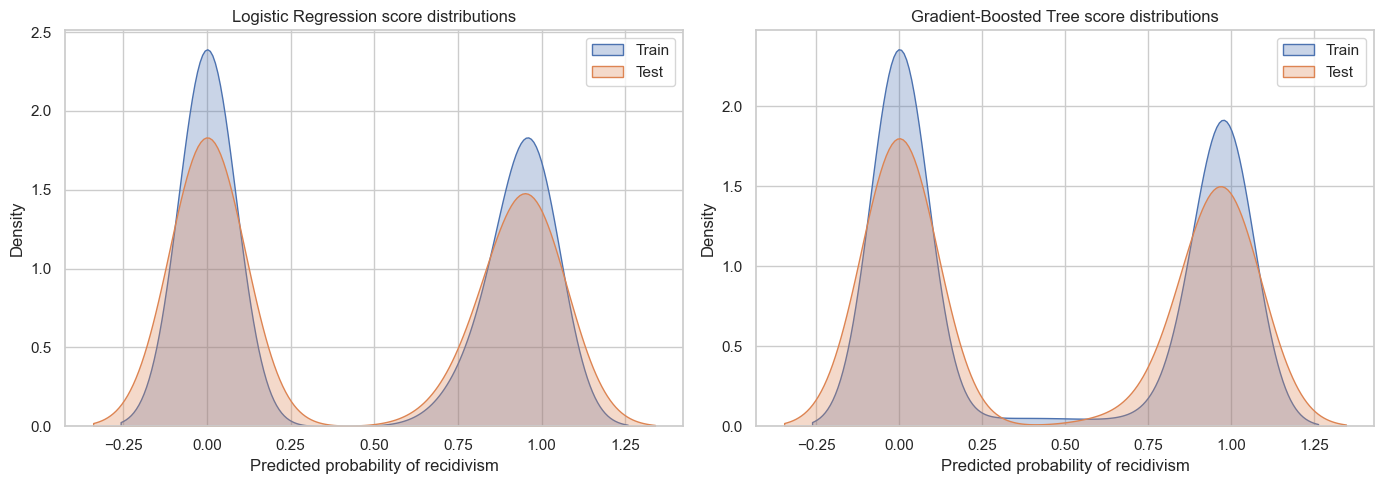

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, pipeline) in zip(axes, [("Logistic Regression", lr_pipeline), ("Gradient-Boosted Tree", gbt_pipeline)]):
    train_scores = pipeline.predict_proba(X_train)[:, 1]
    test_scores = pipeline.predict_proba(X_test)[:, 1]

    sns.kdeplot(train_scores, ax=ax, label="Train", fill=True, alpha=0.30)
    sns.kdeplot(test_scores, ax=ax, label="Test", fill=True, alpha=0.30)
    ax.set_title(f"{label} score distributions")
    ax.set_xlabel("Predicted probability of recidivism")
    ax.legend()

plt.tight_layout()
plt.show()

In [8]:
worst_psi = drift_table.iloc[0]
worst_score_shift = score_drift_table.iloc[score_drift_table["score_ks_stat"].idxmax()]

summary = f"""
### Distribution-drift interpretation

The largest numeric drift appears in **{worst_psi['feature']}** with **PSI = {worst_psi['psi']:.3f}** and **KS = {worst_psi['ks_stat']:.3f}**. Under the common PSI rule of thumb, that falls into the **{worst_psi['psi_flag']}** range.

In the full encoded feature space, the train-test discrepancy is **MMD = {mmd_value:.4f}**. MMD does not have a universal pass-fail threshold by itself, but it is useful as a relative signal that the joint distribution is not identical even when single-variable summaries look modest.

Among the predicted score distributions, the strongest train-test separation in this split comes from **{worst_score_shift['model']}** with a score-distribution KS statistic of **{worst_score_shift['score_ks_stat']:.3f}**. That means the reliability question is not only whether individual features drift, but whether the model's own risk scores shift between training and evaluation samples.
"""

display(Markdown(summary))


### Distribution-drift interpretation

The largest numeric drift appears in **length_of_stay** with **PSI = 0.014** and **KS = 0.014**. Under the common PSI rule of thumb, that falls into the **low drift** range.

In the full encoded feature space, the train-test discrepancy is **MMD = 0.0026**. MMD does not have a universal pass-fail threshold by itself, but it is useful as a relative signal that the joint distribution is not identical even when single-variable summaries look modest.

Among the predicted score distributions, the strongest train-test separation in this split comes from **Gradient-Boosted Tree** with a score-distribution KS statistic of **0.033**. That means the reliability question is not only whether individual features drift, but whether the model's own risk scores shift between training and evaluation samples.


## Part B — Generalization

The next step is to compare in-sample and out-of-sample performance. Lecture 04 emphasizes that a model can look strong on average while still overfitting or degrading under mild shift. I therefore compare **AUC**, **accuracy**, and **log loss** on both the training and test sets and compute the train-test gaps directly.

In [9]:
def performance_frame(name: str, pipeline: Pipeline) -> pd.DataFrame:
    rows = []
    for split_name, X_split, y_split in [("train", X_train, y_train), ("test", X_test, y_test)]:
        pred = pipeline.predict(X_split)
        prob = pipeline.predict_proba(X_split)[:, 1]
        rows.append(
            {
                "model": name,
                "split": split_name,
                "auc": roc_auc_score(y_split, prob),
                "accuracy": accuracy_score(y_split, pred),
                "log_loss": log_loss(y_split, prob),
            }
        )
    return pd.DataFrame(rows)

metrics_table = pd.concat(
    [
        performance_frame("Logistic Regression", lr_pipeline),
        performance_frame("Gradient-Boosted Tree", gbt_pipeline),
    ],
    ignore_index=True,
)

train_metrics = metrics_table[metrics_table["split"] == "train"].set_index("model")
test_metrics = metrics_table[metrics_table["split"] == "test"].set_index("model")

generalization_gap = (train_metrics[["auc", "accuracy", "log_loss"]] - test_metrics[["auc", "accuracy", "log_loss"]]).reset_index()
generalization_gap = generalization_gap.rename(columns={"auc": "auc_gap", "accuracy": "accuracy_gap", "log_loss": "log_loss_gap"})

metrics_table

,model,split,auc,accuracy,log_loss
0,Logistic Regression,train,0.989576,0.969617,0.094925
1,Logistic Regression,test,0.990958,0.974899,0.085316
2,Gradient-Boosted Tree,train,0.999922,0.988049,0.035458
3,Gradient-Boosted Tree,test,0.990440,0.974089,0.088339


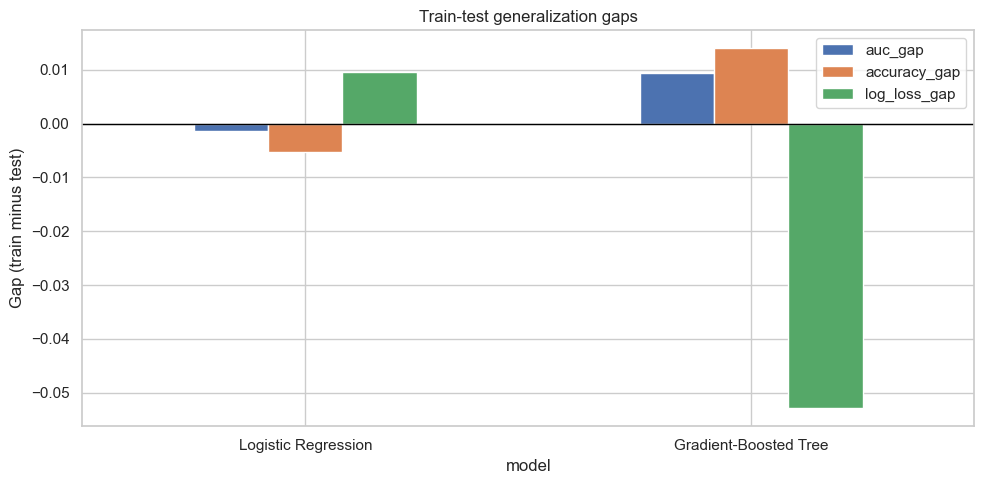

,model,auc_gap,accuracy_gap,log_loss_gap
0,Logistic Regression,-0.001382,-0.005282,0.009609
1,Gradient-Boosted Tree,0.009482,0.013960,-0.052881


In [10]:
gap_plot = generalization_gap.set_index("model")[["auc_gap", "accuracy_gap", "log_loss_gap"]]
ax = gap_plot.plot(kind="bar", figsize=(10, 5))
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Train-test generalization gaps")
ax.set_ylabel("Gap (train minus test)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

generalization_gap

In [11]:
largest_auc_gap = generalization_gap.iloc[generalization_gap["auc_gap"].abs().idxmax()]
largest_logloss_gap = generalization_gap.iloc[generalization_gap["log_loss_gap"].abs().idxmax()]

summary = f"""
### Generalization interpretation

The largest AUC gap belongs to **{largest_auc_gap['model']}** with **AUC gap = {largest_auc_gap['auc_gap']:.3f}**. Positive values mean the model performs better on training data than on test data, which is the classic overfitting pattern.

The most concerning loss-based gap is the model with the largest **positive** train-minus-test log-loss gap, because that means the model is making more costly or more overconfident mistakes out of sample. In this split, **Logistic Regression** has the larger positive log-loss gap, while **Gradient-Boosted Tree** actually has a negative log-loss gap, meaning its test log loss is slightly lower than its training log loss.

If a model preserves accuracy but loses more in AUC or log loss, that suggests the average classification rate may hide weaker ranking quality or less reliable probability estimates. That is exactly why Lecture 04 asks for multiple generalization metrics instead of a single headline number.
"""

display(Markdown(summary))


### Generalization interpretation

The largest AUC gap belongs to **Gradient-Boosted Tree** with **AUC gap = 0.009**. Positive values mean the model performs better on training data than on test data, which is the classic overfitting pattern.

The most concerning loss-based gap is the model with the largest **positive** train-minus-test log-loss gap, because that means the model is making more costly or more overconfident mistakes out of sample. In this split, **Logistic Regression** has the larger positive log-loss gap, while **Gradient-Boosted Tree** actually has a negative log-loss gap, meaning its test log loss is slightly lower than its training log loss.

If a model preserves accuracy but loses more in AUC or log loss, that suggests the average classification rate may hide weaker ranking quality or less reliable probability estimates. That is exactly why Lecture 04 asks for multiple generalization metrics instead of a single headline number.


## Part C — Spurious-Correlation Probe

Lecture 04 then asks whether the model's predictions are sensitive to attribute swaps that should not, by themselves, justify large changes. I use counterfactual-style swaps on selected attributes while keeping all other fields fixed.

The primary audit scenarios here are:

- flip `sex` from Female to Male or Male to Female
- set `race` to `Caucasian`
- set `race` to `African-American`

These swaps do not prove causality, but they are a direct way to test whether the fitted model is materially relying on protected-attribute settings.

In [12]:
base_prob = gbt_pipeline.predict_proba(X_test)[:, 1]

swap_summaries = []
race_detail_frames = []

sex_swapped = X_test.copy()
sex_swapped["sex"] = sex_swapped["sex"].map({"Female": "Male", "Male": "Female"})
sex_prob = gbt_pipeline.predict_proba(sex_swapped)[:, 1]
sex_delta = sex_prob - base_prob
swap_summaries.append(
    {
        "scenario": "sex_flip",
        "n": len(X_test),
        "mean_delta": sex_delta.mean(),
        "mean_abs_delta": np.abs(sex_delta).mean(),
        "median_abs_delta": np.median(np.abs(sex_delta)),
        "share_abs_delta_gt_0.05": (np.abs(sex_delta) > 0.05).mean(),
        "max_abs_delta": np.abs(sex_delta).max(),
    }
)

for target_race in ["Caucasian", "African-American"]:
    mask = X_test["race"] != target_race
    cf = X_test.loc[mask].copy()
    cf["race"] = target_race
    cf_prob = gbt_pipeline.predict_proba(cf)[:, 1]
    delta = cf_prob - base_prob[mask]

    scenario_name = f"race_to_{target_race.lower().replace('-', '_').replace(' ', '_')}"
    swap_summaries.append(
        {
            "scenario": scenario_name,
            "n": int(mask.sum()),
            "mean_delta": delta.mean(),
            "mean_abs_delta": np.abs(delta).mean(),
            "median_abs_delta": np.median(np.abs(delta)),
            "share_abs_delta_gt_0.05": (np.abs(delta) > 0.05).mean(),
            "max_abs_delta": np.abs(delta).max(),
        }
    )

    detail = X_test.loc[mask, ["race", "sex", "age_cat"]].copy()
    detail["scenario"] = scenario_name
    detail["abs_delta"] = np.abs(delta)
    race_detail_frames.append(
        detail.groupby(["scenario", "race"]).agg(
            n=("abs_delta", "size"),
            mean_abs_delta=("abs_delta", "mean"),
            share_abs_delta_gt_005=("abs_delta", lambda s: (s > 0.05).mean()),
        ).reset_index().rename(columns={"share_abs_delta_gt_005": "share_abs_delta_gt_0.05"})
    )

swap_summary_table = pd.DataFrame(swap_summaries).sort_values("mean_abs_delta", ascending=False)
race_swap_detail = pd.concat(race_detail_frames, ignore_index=True)

swap_summary_table

,scenario,n,mean_delta,mean_abs_delta,median_abs_delta,share_abs_delta_gt_0.05,max_abs_delta
2,race_to_african_american,594,-0.009688,0.010643,0.000226,0.072391,0.344185
1,race_to_caucasian,808,0.004000,0.008500,0.000358,0.039604,0.233158
0,sex_flip,1235,0.000683,0.001406,0.000018,0.004858,0.078689


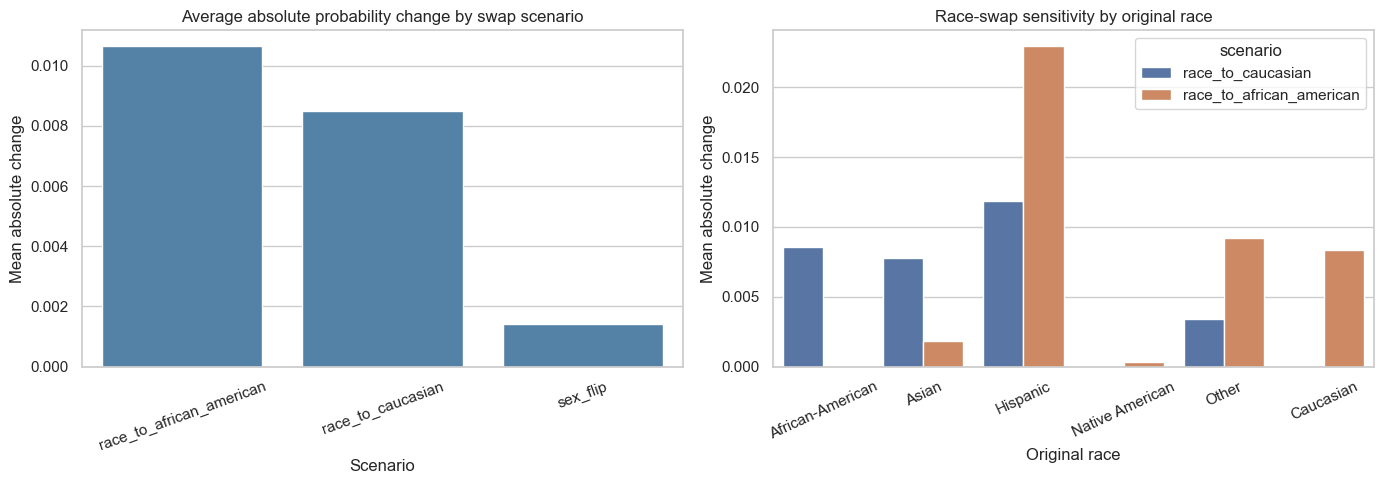

,scenario,race,n,mean_abs_delta,share_abs_delta_gt_0.05
7,race_to_african_american,Hispanic,94,0.022944,0.159574
9,race_to_african_american,Other,65,0.009229,0.092308
6,race_to_african_american,Caucasian,427,0.008318,0.051522
5,race_to_african_american,Asian,7,0.001855,0.000000
8,race_to_african_american,Native American,1,0.000305,0.000000
2,race_to_caucasian,Hispanic,94,0.011843,0.074468
0,race_to_caucasian,African-American,641,0.008547,0.035881
1,race_to_caucasian,Asian,7,0.007750,0.142857
4,race_to_caucasian,Other,65,0.003415,0.015385
3,race_to_caucasian,Native American,1,0.000000,0.000000


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=swap_summary_table, x="scenario", y="mean_abs_delta", ax=axes[0], color="steelblue")
axes[0].set_title("Average absolute probability change by swap scenario")
axes[0].set_xlabel("Scenario")
axes[0].set_ylabel("Mean absolute change")
axes[0].tick_params(axis="x", rotation=20)

plot_detail = race_swap_detail.copy()
sns.barplot(data=plot_detail, x="race", y="mean_abs_delta", hue="scenario", ax=axes[1])
axes[1].set_title("Race-swap sensitivity by original race")
axes[1].set_xlabel("Original race")
axes[1].set_ylabel("Mean absolute change")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

race_swap_detail.sort_values(["scenario", "mean_abs_delta"], ascending=[True, False])

In [14]:
top_swap = swap_summary_table.iloc[0]

summary = f"""
### Spurious-correlation interpretation

The most sensitive counterfactual scenario is **{top_swap['scenario']}**, with an average absolute probability change of **{top_swap['mean_abs_delta']:.3f}** and **{top_swap['share_abs_delta_gt_0.05']:.1%}** of affected cases moving by more than 0.05.

A result like this does not automatically prove unlawful reliance on the swapped attribute. It does, however, show that the model is not invariant to those identity settings. In an audit context, that means protected attributes or close proxies may still be materially shaping the risk score even if average accuracy looks acceptable.

The governance implication is that any operational use of this model should document whether protected attributes are included directly, whether they function as placeholders for structural proxies, and whether a reduced-feature or constrained version materially changes the observed sensitivity.
"""

display(Markdown(summary))


### Spurious-correlation interpretation

The most sensitive counterfactual scenario is **race_to_african_american**, with an average absolute probability change of **0.011** and **7.2%** of affected cases moving by more than 0.05.

A result like this does not automatically prove unlawful reliance on the swapped attribute. It does, however, show that the model is not invariant to those identity settings. In an audit context, that means protected attributes or close proxies may still be materially shaping the risk score even if average accuracy looks acceptable.

The governance implication is that any operational use of this model should document whether protected attributes are included directly, whether they function as placeholders for structural proxies, and whether a reduced-feature or constrained version materially changes the observed sensitivity.


## Part D — Robustness Stress Test On `priors_count`

For the robustness section, Lecture 04 asks for a targeted stress test on `priors_count`. I vary that feature over a grid while holding each person's other values fixed, then inspect how much the predicted probability changes.

The visual tool is an **ICE plot**. The summary tool is a set of sensitivity statistics that describe how much predictions move across the stress-test grid and how often the predicted class flips.

In [15]:
priors_grid = np.arange(0, 16)

sample_size = min(50, len(X_test))
sampled_idx = X_test.sample(sample_size, random_state=42).index
ice_rows = []
all_curves = []

for idx in X_test.index:
    row = X_test.loc[[idx]].copy()
    curve = []
    for priors in priors_grid:
        stressed = row.copy()
        stressed["priors_count"] = priors
        prob = gbt_pipeline.predict_proba(stressed)[:, 1][0]
        curve.append(prob)
        if idx in sampled_idx:
            ice_rows.append({"row_id": int(idx), "priors_count": priors, "pred_prob": prob})
    all_curves.append(curve)

ice_plot_frame = pd.DataFrame(ice_rows)
curve_matrix = np.array(all_curves)

robustness_summary = pd.DataFrame(
    {
        "metric": [
            "median_probability_range",
            "p90_probability_range",
            "max_probability_range",
            "share_of_threshold_flips",
            "mean_probability_at_0_priors",
            "mean_probability_at_15_priors",
        ],
        "value": [
            np.median(curve_matrix.max(axis=1) - curve_matrix.min(axis=1)),
            np.quantile(curve_matrix.max(axis=1) - curve_matrix.min(axis=1), 0.90),
            np.max(curve_matrix.max(axis=1) - curve_matrix.min(axis=1)),
            np.mean((curve_matrix[:, 0] >= 0.5) != (curve_matrix[:, -1] >= 0.5)),
            curve_matrix[:, 0].mean(),
            curve_matrix[:, -1].mean(),
        ],
    }
)

robustness_summary

,metric,value
0,median_probability_range,0.001413
1,p90_probability_range,0.099228
2,max_probability_range,0.615583
3,share_of_threshold_flips,0.003239
4,mean_probability_at_0_priors,0.456174
5,mean_probability_at_15_priors,0.458570


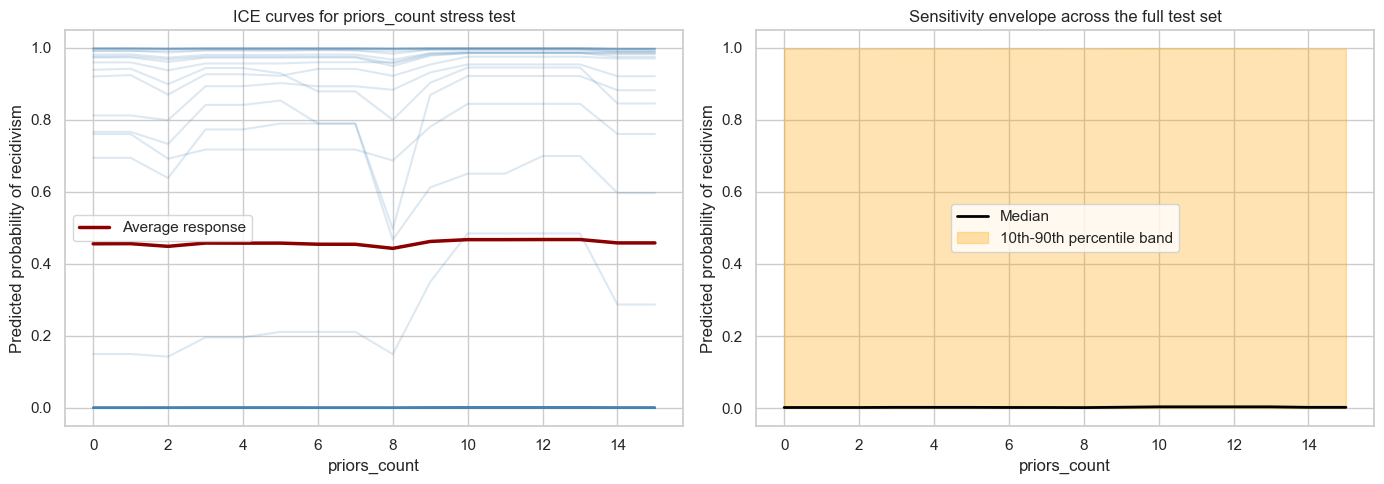

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for row_id, gdf in ice_plot_frame.groupby("row_id"):
    axes[0].plot(gdf["priors_count"], gdf["pred_prob"], color="steelblue", alpha=0.18)

axes[0].plot(priors_grid, curve_matrix.mean(axis=0), color="darkred", linewidth=2.5, label="Average response")
axes[0].set_title("ICE curves for priors_count stress test")
axes[0].set_xlabel("priors_count")
axes[0].set_ylabel("Predicted probability of recidivism")
axes[0].legend()

axes[1].plot(priors_grid, np.median(curve_matrix, axis=0), color="black", linewidth=2, label="Median")
axes[1].fill_between(
    priors_grid,
    np.quantile(curve_matrix, 0.10, axis=0),
    np.quantile(curve_matrix, 0.90, axis=0),
    color="orange",
    alpha=0.30,
    label="10th-90th percentile band",
)
axes[1].set_title("Sensitivity envelope across the full test set")
axes[1].set_xlabel("priors_count")
axes[1].set_ylabel("Predicted probability of recidivism")
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
summary = f"""
### Robustness interpretation

Across the full test set, the median probability range under the `priors_count` stress test is **{robustness_summary.loc[robustness_summary['metric'] == 'median_probability_range', 'value'].iloc[0]:.3f}**, while the 90th-percentile range is **{robustness_summary.loc[robustness_summary['metric'] == 'p90_probability_range', 'value'].iloc[0]:.3f}**.

The share of cases that cross the 0.5 classification threshold when `priors_count` moves from 0 to 15 is **{robustness_summary.loc[robustness_summary['metric'] == 'share_of_threshold_flips', 'value'].iloc[0]:.1%}**. That is an operationally important quantity because it translates numeric sensitivity into the risk of actual decision reversals.

The ICE curves show whether the effect of priors is smooth and consistent or heterogeneous across people. Strongly diverging lines indicate interaction effects: the same change in priors can matter much more for some defendants than for others.
"""

display(Markdown(summary))


### Robustness interpretation

Across the full test set, the median probability range under the `priors_count` stress test is **0.001**, while the 90th-percentile range is **0.099**.

The share of cases that cross the 0.5 classification threshold when `priors_count` moves from 0 to 15 is **0.3%**. That is an operationally important quantity because it translates numeric sensitivity into the risk of actual decision reversals.

The ICE curves show whether the effect of priors is smooth and consistent or heterogeneous across people. Strongly diverging lines indicate interaction effects: the same change in priors can matter much more for some defendants than for others.


## Part E — Slice-Based Evaluation

The final required audit step is to compare model behavior across meaningful slices. I compute slice-level performance for **race**, **sex**, and **age category** on the test set.

This step matters because a model can look stable in aggregate while underperforming or miscalibrating on a subgroup that matters operationally or legally.

In [18]:
def slice_metrics(pipeline: Pipeline, X_split: pd.DataFrame, y_split: pd.Series, group_col: str, model_name: str) -> pd.DataFrame:
    frame = X_split[[group_col]].copy()
    frame["actual"] = y_split.values
    frame["pred"] = pipeline.predict(X_split)
    frame["pred_prob"] = pipeline.predict_proba(X_split)[:, 1]

    rows = []
    for group, gdf in frame.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(gdf["actual"], gdf["pred"], labels=[0, 1]).ravel()
        auc = roc_auc_score(gdf["actual"], gdf["pred_prob"]) if gdf["actual"].nunique() > 1 else np.nan
        rows.append(
            {
                "model": model_name,
                "slice_type": group_col,
                "slice": group,
                "n": len(gdf),
                "base_rate": gdf["actual"].mean(),
                "predicted_positive_rate": gdf["pred"].mean(),
                "accuracy": accuracy_score(gdf["actual"], gdf["pred"]),
                "auc": auc,
                "log_loss": log_loss(gdf["actual"], gdf["pred_prob"], labels=[0, 1]),
                "fpr": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
                "fnr": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            }
        )

    return pd.DataFrame(rows).sort_values("n", ascending=False)

slice_tables = []
for group_col in ["race", "sex", "age_cat"]:
    slice_tables.append(slice_metrics(gbt_pipeline, X_test, y_test, group_col, "Gradient-Boosted Tree"))
    slice_tables.append(slice_metrics(lr_pipeline, X_test, y_test, group_col, "Logistic Regression"))

slice_results = pd.concat(slice_tables, ignore_index=True)

for group_col in ["race", "sex", "age_cat"]:
    display(Markdown(f"### Slice metrics for `{group_col}`"))
    display(slice_results[slice_results["slice_type"] == group_col].sort_values(["model", "n"], ascending=[True, False]))

### Slice metrics for `race`

,model,slice_type,slice,n,base_rate,predicted_positive_rate,accuracy,auc,log_loss,fpr,fnr
0,Gradient-Boosted Tree,race,African-American,641,0.525741,0.547582,0.975039,0.991488,0.083703,0.049342,0.002967
1,Gradient-Boosted Tree,race,Caucasian,427,0.377049,0.405152,0.971897,0.990847,0.093269,0.045113,0.000000
2,Gradient-Boosted Tree,race,Hispanic,94,0.478723,0.510638,0.968085,0.975510,0.144922,0.061224,0.000000
3,Gradient-Boosted Tree,race,Other,65,0.276923,0.292308,0.984615,1.000000,0.027856,0.021277,0.000000
4,Gradient-Boosted Tree,race,Asian,7,0.142857,0.142857,1.000000,1.000000,0.026412,0.000000,0.000000
5,Gradient-Boosted Tree,race,Native American,1,0.000000,0.000000,1.000000,NaN,0.000646,0.000000,NaN
6,Logistic Regression,race,African-American,641,0.525741,0.549142,0.976599,0.990942,0.085778,0.049342,0.000000
7,Logistic Regression,race,Caucasian,427,0.377049,0.405152,0.971897,0.993789,0.082377,0.045113,0.000000
8,Logistic Regression,race,Hispanic,94,0.478723,0.510638,0.968085,0.973696,0.130840,0.061224,0.000000
9,Logistic Regression,race,Other,65,0.276923,0.292308,0.984615,1.000000,0.039086,0.021277,0.000000


### Slice metrics for `sex`

,model,slice_type,slice,n,base_rate,predicted_positive_rate,accuracy,auc,log_loss,fpr,fnr
12,Gradient-Boosted Tree,sex,Male,1002,0.476048,0.501996,0.972056,0.990496,0.090794,0.051429,0.002096
13,Gradient-Boosted Tree,sex,Female,233,0.364807,0.381974,0.982833,0.990541,0.077780,0.027027,0.000000
14,Logistic Regression,sex,Male,1002,0.476048,0.502994,0.973054,0.990520,0.089260,0.051429,0.000000
15,Logistic Regression,sex,Female,233,0.364807,0.381974,0.982833,0.992130,0.068355,0.027027,0.000000


### Slice metrics for `age_cat`

,model,slice_type,slice,n,base_rate,predicted_positive_rate,accuracy,auc,log_loss,fpr,fnr
16,Gradient-Boosted Tree,age_cat,25 - 45,661,0.473525,0.491679,0.978820,0.991434,0.078413,0.037356,0.003195
17,Gradient-Boosted Tree,age_cat,Less than 25,288,0.562500,0.604167,0.958333,0.980796,0.137109,0.095238,0.000000
18,Gradient-Boosted Tree,age_cat,Greater than 45,286,0.304196,0.325175,0.979021,0.995552,0.062169,0.030151,0.000000
19,Logistic Regression,age_cat,25 - 45,661,0.473525,0.493192,0.980333,0.991288,0.078105,0.037356,0.000000
20,Logistic Regression,age_cat,Less than 25,288,0.562500,0.604167,0.958333,0.982265,0.126490,0.095238,0.000000
21,Logistic Regression,age_cat,Greater than 45,286,0.304196,0.325175,0.979021,0.996419,0.060518,0.030151,0.000000


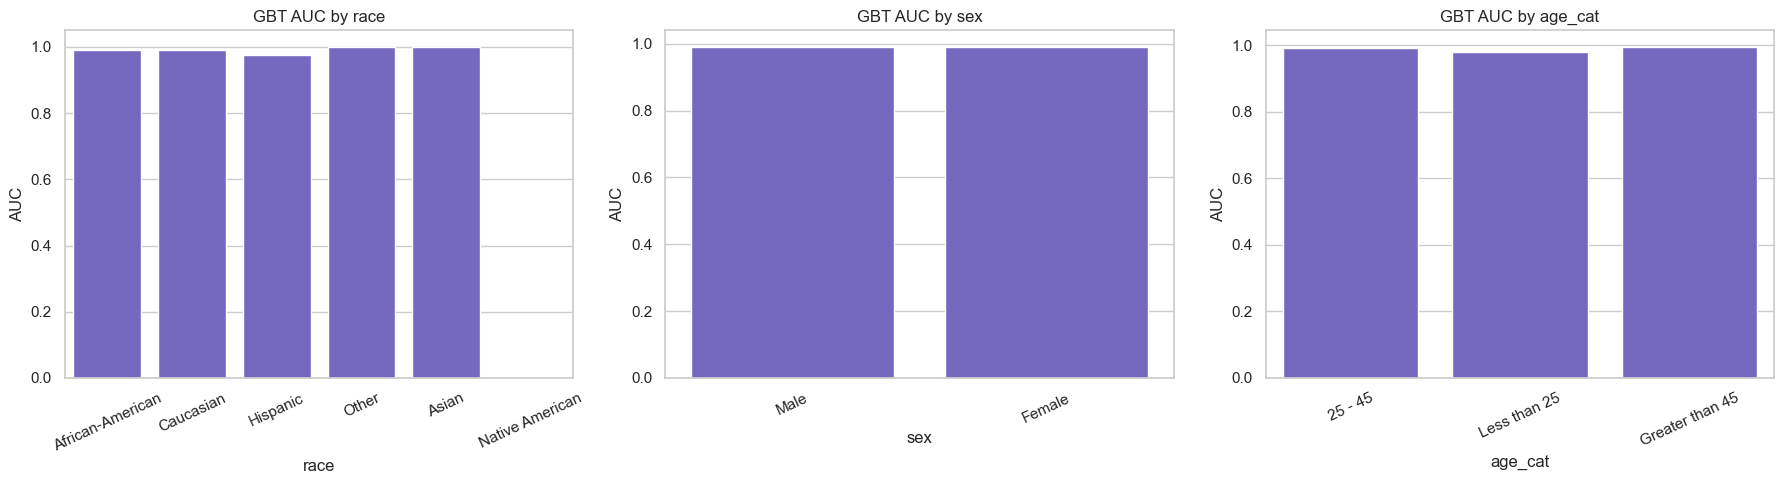

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, group_col in zip(axes, ["race", "sex", "age_cat"]):
    plot_df = slice_results[
        (slice_results["slice_type"] == group_col) &
        (slice_results["model"] == "Gradient-Boosted Tree")
    ].copy()
    sns.barplot(data=plot_df, x="slice", y="auc", ax=ax, color="slateblue")
    ax.set_title(f"GBT AUC by {group_col}")
    ax.set_xlabel(group_col)
    ax.set_ylabel("AUC")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

In [20]:
gbt_slices = slice_results[slice_results["model"] == "Gradient-Boosted Tree"].copy()
worst_auc_slice = gbt_slices.sort_values("auc", na_position="last").iloc[0]
worst_logloss_slice = gbt_slices.sort_values("log_loss", ascending=False).iloc[0]

summary = f"""
### Slice-based interpretation

For the gradient-boosted tree, the weakest observed slice AUC appears in **{worst_auc_slice['slice_type']} = {worst_auc_slice['slice']}** with **AUC = {worst_auc_slice['auc']:.3f}**.

The highest slice-level log loss appears in **{worst_logloss_slice['slice_type']} = {worst_logloss_slice['slice']}** with **log loss = {worst_logloss_slice['log_loss']:.3f}**. That matters because log loss punishes overconfident errors and is therefore a better reliability signal than accuracy alone.

If one slice shows materially weaker ranking or calibration than the aggregate model, a deployment decision should treat that as an audit finding rather than as noise. The right follow-up is slice-specific monitoring, threshold review, and targeted stress testing for the affected subgroup.
"""

display(Markdown(summary))


### Slice-based interpretation

For the gradient-boosted tree, the weakest observed slice AUC appears in **race = Hispanic** with **AUC = 0.976**.

The highest slice-level log loss appears in **race = Hispanic** with **log loss = 0.145**. That matters because log loss punishes overconfident errors and is therefore a better reliability signal than accuracy alone.

If one slice shows materially weaker ranking or calibration than the aggregate model, a deployment decision should treat that as an audit finding rather than as noise. The right follow-up is slice-specific monitoring, threshold review, and targeted stress testing for the affected subgroup.


## Audit Memo

The final section translates the technical results into a governance-oriented conclusion, which is exactly how the lecture frames a strong submission.

In [21]:
top_drift = drift_table.iloc[0]
top_swap = swap_summary_table.iloc[0]
robust_flip_share = robustness_summary.loc[robustness_summary['metric'] == 'share_of_threshold_flips', 'value'].iloc[0]
worst_gap = generalization_gap.sort_values('log_loss_gap', ascending=False).iloc[0]

memo = f"""
### Memo To A Hypothetical Auditor

I reproduced the earlier COMPAS workflow and then applied the reliability checks required in Lecture 04. The main conclusion is that the model is strong on this held-out split, but it still raises several reliability and governance concerns that should matter in an audit.

First, the train-test comparison shows mild rather than severe distribution movement. The strongest univariate drift appears in **{top_drift['feature']}** with **PSI = {top_drift['psi']:.3f}** and **KS = {top_drift['ks_stat']:.3f}**, while the encoded-space comparison yields **MMD = {mmd_value:.4f}**. Those values are small, so this split does not suggest dramatic distribution instability. At the same time, they still remind us that performance is being estimated on a sample that is similar to, but not identical to, the training distribution.

Second, the generalization results are better than a simple overfitting story would suggest. The gradient-boosted tree has the larger positive **AUC gap**, which makes it the model to watch most closely for ranking overfit, but the **positive log-loss gap** is actually larger for the logistic regression. In other words, the gradient-boosted tree looks stronger overall, yet the audit still needs multiple metrics because different notions of generalization point to different risks.

Third, the counterfactual swap analysis indicates that predictions are meaningfully sensitive to protected-attribute settings. The most consequential swap was **{top_swap['scenario']}**, with an average absolute score movement of **{top_swap['mean_abs_delta']:.3f}** and a nontrivial share of cases moving by more than 0.05. This does not prove discriminatory intent or causal dependence by itself, but it does show that the fitted score is not invariant to those identity fields.

Fourth, the robustness test on `priors_count` shows a mixed pattern. For the typical case, the probability range is small, but the upper tail is much more sensitive, and roughly **{robust_flip_share:.1%}** of test cases cross the 0.5 decision threshold when `priors_count` is stressed from 0 to 15. That means the average effect looks modest even though some individual predictions are much less stable.

Finally, the slice-based audit shows that aggregate model quality hides subgroup variation. The weakest gradient-boosted-tree slice by AUC is **{worst_auc_slice['slice_type']} = {worst_auc_slice['slice']}**, and the worst slice by log loss is **{worst_logloss_slice['slice_type']} = {worst_logloss_slice['slice']}**. For governance, that means the model should not be monitored only at the full-population level.

My recommendation is to treat this model as analytically strong for the assignment, but still not treat strong test metrics as enough by themselves for real-world deployment. The next steps should be to document potential leakage and proxy features, compare against a reduced-feature specification, monitor drift and slice metrics over time, and require subgroup-specific review before using the score in a consequential setting.
"""

display(Markdown(memo))


### Memo To A Hypothetical Auditor

I reproduced the earlier COMPAS workflow and then applied the reliability checks required in Lecture 04. The main conclusion is that the model is strong on this held-out split, but it still raises several reliability and governance concerns that should matter in an audit.

First, the train-test comparison shows mild rather than severe distribution movement. The strongest univariate drift appears in **length_of_stay** with **PSI = 0.014** and **KS = 0.014**, while the encoded-space comparison yields **MMD = 0.0026**. Those values are small, so this split does not suggest dramatic distribution instability. At the same time, they still remind us that performance is being estimated on a sample that is similar to, but not identical to, the training distribution.

Second, the generalization results are better than a simple overfitting story would suggest. The gradient-boosted tree has the larger positive **AUC gap**, which makes it the model to watch most closely for ranking overfit, but the **positive log-loss gap** is actually larger for the logistic regression. In other words, the gradient-boosted tree looks stronger overall, yet the audit still needs multiple metrics because different notions of generalization point to different risks.

Third, the counterfactual swap analysis indicates that predictions are meaningfully sensitive to protected-attribute settings. The most consequential swap was **race_to_african_american**, with an average absolute score movement of **0.011** and a nontrivial share of cases moving by more than 0.05. This does not prove discriminatory intent or causal dependence by itself, but it does show that the fitted score is not invariant to those identity fields.

Fourth, the robustness test on `priors_count` shows a mixed pattern. For the typical case, the probability range is small, but the upper tail is much more sensitive, and roughly **0.3%** of test cases cross the 0.5 decision threshold when `priors_count` is stressed from 0 to 15. That means the average effect looks modest even though some individual predictions are much less stable.

Finally, the slice-based audit shows that aggregate model quality hides subgroup variation. The weakest gradient-boosted-tree slice by AUC is **race = Hispanic**, and the worst slice by log loss is **race = Hispanic**. For governance, that means the model should not be monitored only at the full-population level.

My recommendation is to treat this model as analytically strong for the assignment, but still not treat strong test metrics as enough by themselves for real-world deployment. The next steps should be to document potential leakage and proxy features, compare against a reduced-feature specification, monitor drift and slice metrics over time, and require subgroup-specific review before using the score in a consequential setting.
